# Mode 2: Online Bayesian Meal Identification On Real CGM Data

This notebook tests the fixed-meal-parameter idea:

```text
A_meal = fixed pulse height for this meal
T_meal = fixed pulse width for this meal
p(A,T | CGM up to current time) is updated online
```

There is no Kalman state correction here. Every candidate `(A,T)` defines a full deterministic glucose trajectory. As new CGM values arrive, we update the posterior weight of each trajectory. This makes the meal identification interpretable: uncertainty moves over fixed meal-response parameters instead of drifting hidden parameters over time.


In [1]:
# =========================================================
# IMPORTS AND REAL DATA LOADING
# =========================================================

import os
import sys
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm

ROOT_DIR = Path.cwd()
if ROOT_DIR.name == "nbs":
    ROOT_DIR = ROOT_DIR.parent

sys.path.append(str(ROOT_DIR))

from glucose_model.data.preprocess import (
    clean_response,
    clean_sleep,
    aggregate_activity,
    attach_context,
    interpolate_meal,
    normalize_context,
)
from glucose_model.data.dataset import GlucoseDataset


df_activity = pd.read_csv(ROOT_DIR / "data/processed/activity_data.csv")
df_sleep = pd.read_csv(ROOT_DIR / "data/processed/sleep_data.csv")
df_response = pd.read_csv(ROOT_DIR / "data/processed/t2d_long_format.csv")

print("Activity:", df_activity.shape)
print("Sleep:   ", df_sleep.shape)
print("Response:", df_response.shape)
print("time_meal range:", df_response["time_meal"].min(), df_response["time_meal"].max())


Activity: (16217, 8)
Sleep:    (687, 8)
Response: (143118, 33)
time_meal range: -30 360


/tmp/ipykernel_104818/34112815.py:35: DtypeWarning: Columns (0: Snack pre/post) have mixed types. Specify dtype option on import or set low_memory=False.
  df_response = pd.read_csv(ROOT_DIR / "data/processed/t2d_long_format.csv")


In [2]:
# =========================================================
# BUILD REAL MEAL WINDOWS WITH PREMEAL TIME PRESERVED
# =========================================================


def build_meal_trajectories_with_premeal(df, min_time=-30, min_post_time=60):
    meals = []

    for meal_id, g in df.groupby("abs_ID"):
        g = g.sort_values("time_meal")

        t = pd.to_numeric(g["time_meal"], errors="coerce").to_numpy(dtype=float)
        glucose = pd.to_numeric(g["Glucose"], errors="coerce").to_numpy(dtype=float)

        valid = np.isfinite(t) & np.isfinite(glucose)
        t = t[valid]
        glucose = glucose[valid]

        if len(t) < 4:
            continue
        if np.nanmin(t) > min_time or np.nanmax(t) < min_post_time:
            continue

        meal = {
            "person_id": int(g["ID"].iloc[0]),
            "meal_id": meal_id,
            "meal_type": g["Meal type"].iloc[0],
            "meal": {
                "carbs": float(g["CHO_g"].iloc[0]),
                "fat": float(g["Fat_g"].iloc[0]),
                "protein": float(g["Prot_g"].iloc[0]),
            },
            "time": t,
            "glucose": glucose,
            "day": g["Day number"].iloc[0],
        }

        meals.append(meal)

    return meals


df_response_clean = clean_response(df_response)
df_sleep_clean = clean_sleep(df_sleep)
df_activity_agg = aggregate_activity(df_activity)

meals = build_meal_trajectories_with_premeal(df_response_clean)
meals = attach_context(meals, df_sleep_clean, df_activity_agg)

t_grid = np.arange(-30, 181, 5)
meals_interp = [interpolate_meal(m, t_grid) for m in meals]
meals_interp, context_mean, context_std = normalize_context(meals_interp)

person_ids = sorted(set(m["person_id"] for m in meals_interp))
person_to_idx = {pid: i for i, pid in enumerate(person_ids)}
for m in meals_interp:
    m["person_idx"] = person_to_idx[m["person_id"]]

mode2_dataset = GlucoseDataset(meals_interp)

print(f"Meal windows: {len(mode2_dataset)}")
print(f"People:       {len(person_ids)}")
print(f"Time grid:    {t_grid[0]} to {t_grid[-1]} min, n={len(t_grid)}")


Meal windows: 2126
People:       105
Time grid:    -30 to 180 min, n=43


In [3]:
# =========================================================
# TRAIN / TEST SPLIT BY PERSON
# =========================================================


def split_meals_by_person(ds, train_frac=0.70, min_train=5, min_test=2):
    by_person = defaultdict(list)

    for idx, meal in enumerate(ds.meals):
        by_person[int(meal["person_id"])].append(idx)

    train_idx = []
    test_idx = []

    for person_id, indices in by_person.items():
        indices = list(indices)
        n = len(indices)

        if n < min_train + min_test:
            continue

        n_train = int(np.floor(train_frac * n))
        n_train = min(max(n_train, min_train), n - min_test)

        train_idx.extend(indices[:n_train])
        test_idx.extend(indices[n_train:])

    return train_idx, test_idx


train_idx, test_idx = split_meals_by_person(mode2_dataset)
print(f"Train meals: {len(train_idx)}")
print(f"Test meals:  {len(test_idx)}")


Train meals: 1448
Test meals:  678


In [4]:
# =========================================================
# SHARED HELPERS
# =========================================================

ACKERMAN_DEFAULT = {
    # Damped oscillator response shape.
    "period": 170.0,
    "zeta": 0.70,
    "k_b": 0.001,

    # Population-level starting guesses for fixed meal parameters.
    "A0": 0.10,
    "T0": 55.0,
}

PARAM_BOUNDS = {
    "A": (0.001, 0.80),
    "T": (5.0, 180.0),
}


def sample_from_dataset(ds, idx):
    sample = ds[idx]
    raw = ds.meals[idx]

    return {
        "idx": idx,
        "meal_id": raw.get("meal_id", idx),
        "meal_type": raw.get("meal_type", "unknown"),
        "person_id": int(sample["person_id"]),
        "person_idx": int(sample["person_idx"]),
        "meal": {
            "carbs": float(sample["meal"]["carbs"]),
            "fat": float(sample["meal"]["fat"]),
            "protein": float(sample["meal"]["protein"]),
        },
        "context": np.asarray(sample["context"], dtype=float),
        "time": np.asarray(sample["time"], dtype=float),
        "glucose": np.asarray(sample["glucose"], dtype=float),
    }


def premeal_summary(sample):
    time = np.asarray(sample["time"], dtype=float)
    glucose = np.asarray(sample["glucose"], dtype=float)
    pre = time < 0

    if np.sum(pre) < 2:
        baseline = float(glucose[0])
        slope = 0.0
    else:
        baseline = float(np.median(glucose[pre]))
        slope = float(np.polyfit(time[pre], glucose[pre], 1)[0])

    return baseline, slope


def response_metrics(time, glucose_curve, baseline=None, threshold=180.0):
    time = np.asarray(time, dtype=float)
    glucose_curve = np.asarray(glucose_curve, dtype=float)
    post = time >= 0

    if baseline is None:
        baseline = float(np.median(glucose_curve[time < 0])) if np.any(time < 0) else float(glucose_curve[0])

    post_time = time[post]
    post_glucose = glucose_curve[post]
    delta = post_glucose - baseline

    return {
        "baseline": baseline,
        "peak": float(np.max(post_glucose)),
        "peak_delta": float(np.max(delta)),
        "iAUC": float(np.trapz(np.maximum(delta, 0.0), post_time)),
        "time_above_180": float(np.sum(post_glucose > threshold) * np.median(np.diff(time))),
    }


def wide_pulse(t, T, edge=3.0):
    z1 = np.clip(t / edge, -60.0, 60.0)
    z2 = np.clip((T - t) / edge, -60.0, 60.0)
    return (1.0 / (1.0 + np.exp(-z1))) * (1.0 / (1.0 + np.exp(-z2)))


def logsumexp(values):
    values = np.asarray(values, dtype=float)
    max_value = np.max(values)
    return float(max_value + np.log(np.sum(np.exp(values - max_value))))


def softmax_log(log_values):
    return np.exp(log_values - logsumexp(log_values))


def weighted_quantile(values, weights, probs):
    values = np.asarray(values, dtype=float).reshape(-1)
    weights = np.asarray(weights, dtype=float).reshape(-1)
    probs = np.asarray(probs, dtype=float)

    order = np.argsort(values)
    values = values[order]
    weights = weights[order]
    cdf = np.cumsum(weights)
    cdf = cdf / cdf[-1]
    return np.interp(probs, cdf, values)


In [5]:
# =========================================================
# DETERMINISTIC ACKERMAN FORECAST FOR FIXED A/T
# =========================================================


def rollout_ackerman_pulse(sample, theta=None, A_meal=None, T_meal=None):
    """
    Deterministic forecast for one fixed meal parameter pair.

    State:
      G = glucose deviation from baseline
      V = response velocity
      B = slowly moving baseline

    A_meal is the fixed pulse height. T_meal is the fixed pulse width.
    """
    theta = {**ACKERMAN_DEFAULT, **(theta or {})}

    time = np.asarray(sample["time"], dtype=float)
    glucose = np.asarray(sample["glucose"], dtype=float)

    A_meal = ACKERMAN_DEFAULT["A0"] if A_meal is None else float(A_meal)
    T_meal = ACKERMAN_DEFAULT["T0"] if T_meal is None else float(T_meal)
    A_meal = float(np.clip(A_meal, *PARAM_BOUNDS["A"]))
    T_meal = float(np.clip(T_meal, *PARAM_BOUNDS["T"]))

    baseline0, pre_slope = premeal_summary(sample)

    omega = 2.0 * np.pi / theta["period"]
    zeta = theta["zeta"]
    k_b = theta["k_b"]

    x = np.array([
        glucose[0] - baseline0,
        pre_slope,
        baseline0,
    ], dtype=float)

    pred = []

    for i, t in enumerate(time):
        pred.append(float(x[0] + x[2]))

        if i == len(time) - 1:
            break

        dt = float(time[i + 1] - time[i])
        n_steps = max(1, int(np.ceil(abs(dt))))
        h = dt / n_steps

        for substep in range(n_steps):
            t_sub = float(t) + substep * h
            pulse = wide_pulse(t_sub, T_meal)

            G, V, B = x

            dG = V
            dV = -(omega ** 2) * G - 2.0 * zeta * omega * V + A_meal * pulse
            dB = -k_b * (B - baseline0)

            x = np.array([
                G + h * dG,
                V + h * dV,
                B + h * dB,
            ], dtype=float)

    pred = np.asarray(pred, dtype=float)

    return {
        "time": time,
        "glucose_obs": glucose,
        "glucose_pred": pred,
        "prediction_residual": glucose - pred,
        "A_meal": A_meal,
        "T_meal": T_meal,
        "theta": theta,
    }


In [6]:
# =========================================================
# OPTIONAL: LEARN PREMEAL PRIORS FOR A/T FROM TRAINING MEALS
# =========================================================


def meal_feature_vector(sample):
    baseline, slope = premeal_summary(sample)
    meal = sample["meal"]
    context = np.asarray(sample.get("context", np.zeros(5)), dtype=float)
    meal_type = context[2:5] if len(context) >= 5 else np.zeros(3)

    return np.array([
        1.0,
        (meal["carbs"] - 70.0) / 50.0,
        (meal["fat"] - 20.0) / 15.0,
        (meal["protein"] - 20.0) / 15.0,
        (baseline - 120.0) / 40.0,
        slope / 0.20,
        *meal_type,
    ], dtype=float)


def fit_ridge(X, y, l2=1.0):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    penalty = l2 * np.eye(X.shape[1])
    penalty[0, 0] = 0.0
    return np.linalg.solve(X.T @ X + penalty, X.T @ y)


def predict_from_ridge(x, coef):
    return float(np.asarray(x) @ np.asarray(coef))


def fit_at_for_completed_meal(sample, theta=None, A_grid=None, T_grid=None):
    theta = {**ACKERMAN_DEFAULT, **(theta or {})}
    A_grid = np.linspace(0.01, 0.28, 18) if A_grid is None else np.asarray(A_grid, dtype=float)
    T_grid = np.linspace(15.0, 165.0, 18) if T_grid is None else np.asarray(T_grid, dtype=float)

    time = sample["time"]
    post = time >= 0
    baseline = float(np.median(sample["glucose"][time < 0])) if np.any(time < 0) else float(sample["glucose"][0])
    obs_metrics = response_metrics(time, sample["glucose"], baseline=baseline)
    post_duration = max(float(time[post][-1] - time[post][0]), 1.0)

    best = None

    for T_meal in T_grid:
        for A_meal in A_grid:
            trace = rollout_ackerman_pulse(sample, theta=theta, A_meal=A_meal, T_meal=T_meal)
            pred = trace["glucose_pred"]
            resid = pred[post] - sample["glucose"][post]

            curve_mse = float(np.mean(resid ** 2))
            pred_metrics = response_metrics(time, pred, baseline=baseline)
            peak_mse = float((pred_metrics["peak"] - obs_metrics["peak"]) ** 2)
            iauc_error_per_min = (pred_metrics["iAUC"] - obs_metrics["iAUC"]) / post_duration
            iauc_mse = float(iauc_error_per_min ** 2)
            loss = curve_mse + 0.5 * peak_mse + 0.25 * iauc_mse

            if best is None or loss < best["loss"]:
                best = {
                    "A_est": float(A_meal),
                    "T_est": float(T_meal),
                    "loss": float(loss),
                }

    return best


def estimate_at_labels(ds, indices, max_meals=80):
    rows = []

    for idx in tqdm(indices[:max_meals]):
        sample = sample_from_dataset(ds, idx)
        best = fit_at_for_completed_meal(sample)
        rows.append({
            "idx": idx,
            "person_id": sample["person_id"],
            "meal_id": sample["meal_id"],
            "A_est": best["A_est"],
            "T_est": best["T_est"],
            "fit_loss": best["loss"],
            "features": meal_feature_vector(sample),
        })

    return rows


MAX_PRIOR_TRAIN_MEALS = 40
at_label_rows = estimate_at_labels(
    mode2_dataset,
    train_idx,
    max_meals=MAX_PRIOR_TRAIN_MEALS,
)

X_prior = np.vstack([r["features"] for r in at_label_rows])
y_log_A = np.log(np.clip([r["A_est"] for r in at_label_rows], PARAM_BOUNDS["A"][0], None))
y_log_T = np.log(np.clip([r["T_est"] for r in at_label_rows], PARAM_BOUNDS["T"][0], PARAM_BOUNDS["T"][1]))

coef_log_A = fit_ridge(X_prior, y_log_A, l2=5.0)
coef_log_T = fit_ridge(X_prior, y_log_T, l2=5.0)


def predict_meal_prior(sample):
    x = meal_feature_vector(sample)
    A = np.exp(predict_from_ridge(x, coef_log_A))
    T = np.exp(predict_from_ridge(x, coef_log_T))
    A = float(np.clip(A, *PARAM_BOUNDS["A"]))
    T = float(np.clip(T, *PARAM_BOUNDS["T"]))
    return A, T


pd.DataFrame(at_label_rows).drop(columns=["features"]).describe()


100%|██████████| 40/40 [01:55<00:00,  2.88s/it]


,idx,person_id,A_est,T_est,fit_loss
count,40.000000,40.000000,40.000000,40.000000,40.000000
mean,25.800000,34.300000,0.137456,79.632353,314.549139
std,16.574927,43.721848,0.065286,54.844646,233.267970
min,0.000000,1.000000,0.010000,15.000000,46.331216
25%,9.750000,1.000000,0.073529,32.647059,160.857415
50%,25.500000,10.000000,0.137059,59.117647,259.857630
75%,42.250000,100.000000,0.184706,138.529412,376.766207
max,52.000000,100.000000,0.280000,165.000000,1288.724769


In [7]:
# =========================================================
# ONLINE BAYESIAN POSTERIOR OVER FIXED A/T
# =========================================================


def make_log_grid(center, lower, upper, n=35, factor_low=0.35, factor_high=3.0):
    center = float(np.clip(center, lower, upper))
    lo = max(lower, center * factor_low)
    hi = min(upper, center * factor_high)
    if hi <= lo:
        lo, hi = lower, upper
    return np.exp(np.linspace(np.log(lo), np.log(hi), int(n)))


def make_linear_grid(center, lower, upper, n=35, width=65.0):
    center = float(np.clip(center, lower, upper))
    lo = max(lower, center - width)
    hi = min(upper, center + width)
    if hi <= lo:
        lo, hi = lower, upper
    return np.linspace(lo, hi, int(n))


def build_log_prior(A_grid, T_grid, A_prior=None, T_prior=None, A_log_sd=0.65, T_log_sd=0.55):
    log_prior = np.zeros((len(T_grid), len(A_grid)), dtype=float)

    if A_prior is not None:
        log_A = np.log(np.asarray(A_grid, dtype=float))
        log_A0 = np.log(float(np.clip(A_prior, *PARAM_BOUNDS["A"])))
        log_prior += -0.5 * ((log_A[None, :] - log_A0) / A_log_sd) ** 2

    if T_prior is not None:
        log_T = np.log(np.asarray(T_grid, dtype=float))
        log_T0 = np.log(float(np.clip(T_prior, *PARAM_BOUNDS["T"])))
        log_prior += -0.5 * ((log_T[:, None] - log_T0) / T_log_sd) ** 2

    return log_prior - logsumexp(log_prior)


def online_meal_posterior(
    sample,
    theta,
    A_grid,
    T_grid,
    sigma=12.0,
    A_prior=None,
    T_prior=None,
    update_start=0.0,
):
    time = np.asarray(sample["time"], dtype=float)
    glucose = np.asarray(sample["glucose"], dtype=float)
    A_grid = np.asarray(A_grid, dtype=float)
    T_grid = np.asarray(T_grid, dtype=float)

    trajectory_array = np.empty((len(T_grid), len(A_grid), len(time)), dtype=float)

    for i, T_meal in enumerate(T_grid):
        for j, A_meal in enumerate(A_grid):
            trace = rollout_ackerman_pulse(
                sample,
                theta=theta,
                A_meal=float(A_meal),
                T_meal=float(T_meal),
            )
            trajectory_array[i, j] = trace["glucose_pred"]

    logpost = build_log_prior(A_grid, T_grid, A_prior=A_prior, T_prior=T_prior)
    posterior_history = []
    logpost_history = []

    for t_idx, t in enumerate(time):
        if t >= update_start:
            resid = glucose[t_idx] - trajectory_array[:, :, t_idx]
            ll = -0.5 * (resid / sigma) ** 2
            logpost = logpost + ll

        logpost = logpost - logsumexp(logpost)
        posterior_history.append(np.exp(logpost).copy())
        logpost_history.append(logpost.copy())

    posterior_history = np.asarray(posterior_history)
    logpost_history = np.asarray(logpost_history)

    A_mean_by_time = np.sum(posterior_history * A_grid[None, None, :], axis=(1, 2))
    T_mean_by_time = np.sum(posterior_history * T_grid[None, :, None], axis=(1, 2))
    A_second = np.sum(posterior_history * (A_grid[None, None, :] ** 2), axis=(1, 2))
    T_second = np.sum(posterior_history * (T_grid[None, :, None] ** 2), axis=(1, 2))

    A_sd_by_time = np.sqrt(np.maximum(A_second - A_mean_by_time ** 2, 0.0))
    T_sd_by_time = np.sqrt(np.maximum(T_second - T_mean_by_time ** 2, 0.0))

    return {
        "time": time,
        "glucose": glucose,
        "A_grid": A_grid,
        "T_grid": T_grid,
        "trajectory_array": trajectory_array,
        "posterior_history": posterior_history,
        "logpost_history": logpost_history,
        "A_mean_by_time": A_mean_by_time,
        "T_mean_by_time": T_mean_by_time,
        "A_sd_by_time": A_sd_by_time,
        "T_sd_by_time": T_sd_by_time,
        "theta": theta,
        "sigma": sigma,
        "A_prior": A_prior,
        "T_prior": T_prior,
    }


def posterior_predictive_summary(result, posterior_idx=-1, q=(0.05, 0.50, 0.95)):
    posterior = result["posterior_history"][posterior_idx]
    trajectories = result["trajectory_array"]

    pred_mean = np.sum(posterior[:, :, None] * trajectories, axis=(0, 1))

    flat_post = posterior.reshape(-1)
    flat_traj = trajectories.reshape(-1, trajectories.shape[-1])
    pred_q = np.vstack([
        weighted_quantile(flat_traj[:, k], flat_post, q)
        for k in range(flat_traj.shape[1])
    ])

    return {
        "mean": pred_mean,
        "low": pred_q[:, 0],
        "median": pred_q[:, 1],
        "high": pred_q[:, 2],
    }


def posterior_parameter_summary(result, posterior_idx=-1):
    posterior = result["posterior_history"][posterior_idx]
    A_grid = result["A_grid"]
    T_grid = result["T_grid"]

    map_idx = np.unravel_index(np.argmax(posterior), posterior.shape)
    A_mean = float(np.sum(posterior * A_grid[None, :]))
    T_mean = float(np.sum(posterior * T_grid[:, None]))
    A_sd = float(np.sqrt(np.sum(posterior * (A_grid[None, :] - A_mean) ** 2)))
    T_sd = float(np.sqrt(np.sum(posterior * (T_grid[:, None] - T_mean) ** 2)))

    return {
        "A_map": float(A_grid[map_idx[1]]),
        "T_map": float(T_grid[map_idx[0]]),
        "A_mean": A_mean,
        "T_mean": T_mean,
        "A_sd": A_sd,
        "T_sd": T_sd,
    }


def index_nearest(time, value):
    return int(np.argmin(np.abs(np.asarray(time, dtype=float) - float(value))))


def index_last_before(time, value):
    time = np.asarray(time, dtype=float)
    candidates = np.where(time < value)[0]
    if len(candidates) == 0:
        return 0
    return int(candidates[-1])


Person: 1
Meal: 1.0_lunch_3
Meal composition: {'carbs': 73.30000305175781, 'fat': 22.299999237060547, 'protein': 16.5}
Prior A/T: 0.1406, 58.8
Premeal posterior mean A/T: 0.1674, 74.8
Final MAP A/T: 0.1296, 60.1
Final mean A/T: 0.1277 +/- 0.0082, 62.2 +/- 3.5


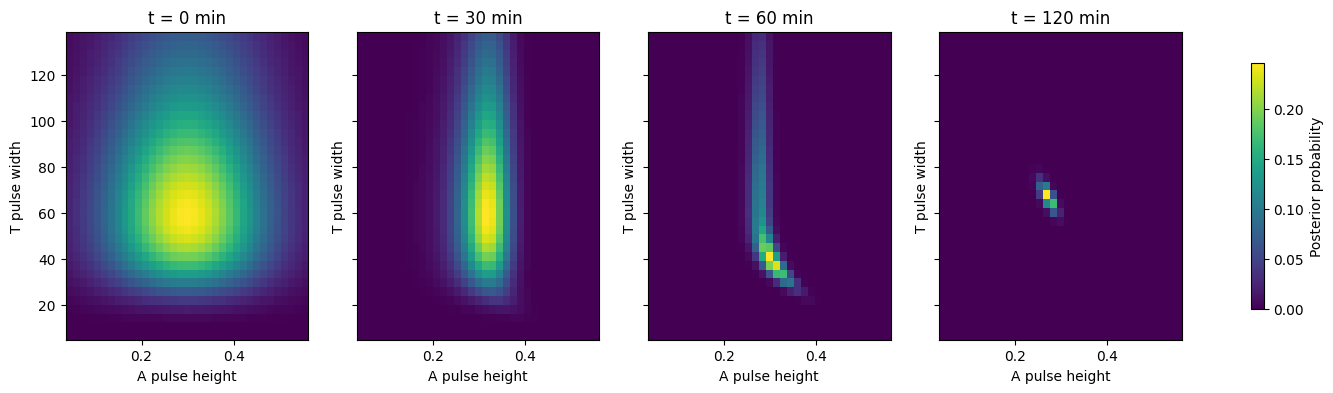

In [8]:
# =========================================================
# HELD-OUT EXAMPLE: ONLINE POSTERIOR IDENTIFICATION
# =========================================================

example_idx = test_idx[0]
example_sample = sample_from_dataset(mode2_dataset, example_idx)
example_theta = dict(ACKERMAN_DEFAULT)
A_prior, T_prior = predict_meal_prior(example_sample)

A_grid = make_log_grid(A_prior, *PARAM_BOUNDS["A"], n=35, factor_low=0.25, factor_high=4.0)
T_grid = make_linear_grid(T_prior, *PARAM_BOUNDS["T"], n=35, width=80.0)

result = online_meal_posterior(
    example_sample,
    example_theta,
    A_grid=A_grid,
    T_grid=T_grid,
    sigma=12.0,
    A_prior=A_prior,
    T_prior=T_prior,
    update_start=0.0,
)

final_summary = posterior_parameter_summary(result, posterior_idx=-1)
pre_idx = index_last_before(result["time"], 0.0)
pre_summary = posterior_parameter_summary(result, posterior_idx=pre_idx)

print("Person:", example_sample["person_id"])
print("Meal:", example_sample["meal_id"])
print("Meal composition:", example_sample["meal"])
print(f"Prior A/T: {A_prior:.4f}, {T_prior:.1f}")
print(f"Premeal posterior mean A/T: {pre_summary['A_mean']:.4f}, {pre_summary['T_mean']:.1f}")
print(f"Final MAP A/T: {final_summary['A_map']:.4f}, {final_summary['T_map']:.1f}")
print(f"Final mean A/T: {final_summary['A_mean']:.4f} +/- {final_summary['A_sd']:.4f}, {final_summary['T_mean']:.1f} +/- {final_summary['T_sd']:.1f}")

snapshots = [
    index_nearest(result["time"], 0),
    index_nearest(result["time"], 30),
    index_nearest(result["time"], 60),
    index_nearest(result["time"], 120),
]

fig, axes = plt.subplots(1, len(snapshots), figsize=(18, 4), sharey=True)

for ax, idx in zip(axes, snapshots):
    posterior = result["posterior_history"][idx]
    im = ax.imshow(
        posterior,
        origin="lower",
        aspect="auto",
        extent=[A_grid[0], A_grid[-1], T_grid[0], T_grid[-1]],
    )
    ax.set_title(f"t = {result['time'][idx]:.0f} min")
    ax.set_xlabel("A pulse height")
    ax.set_ylabel("T pulse width")

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8, label="Posterior probability")
plt.show()


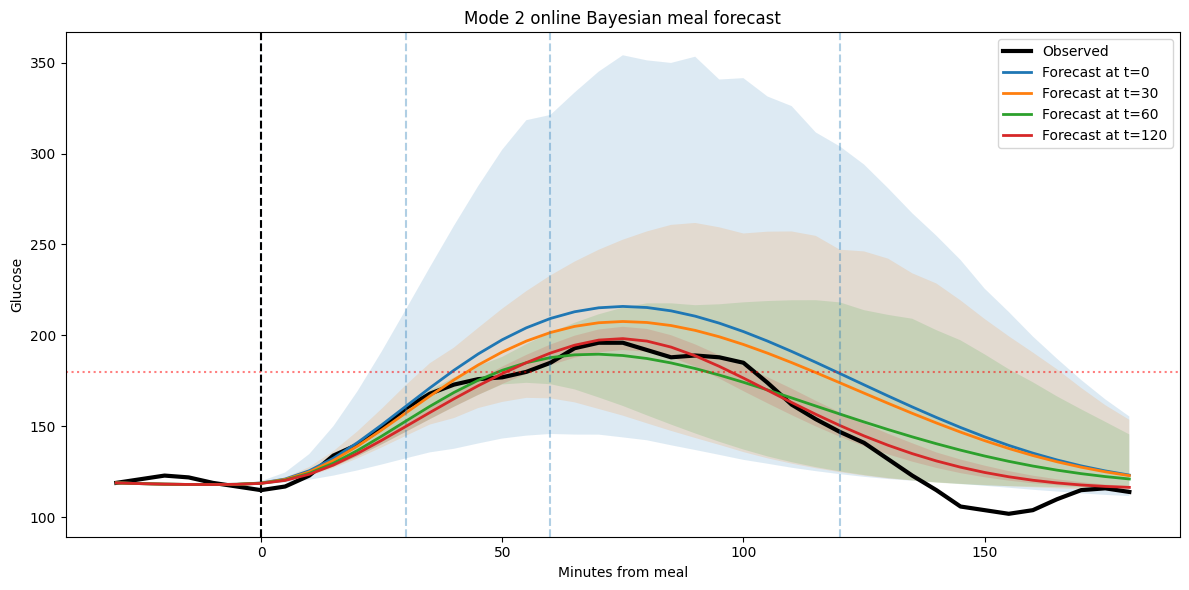

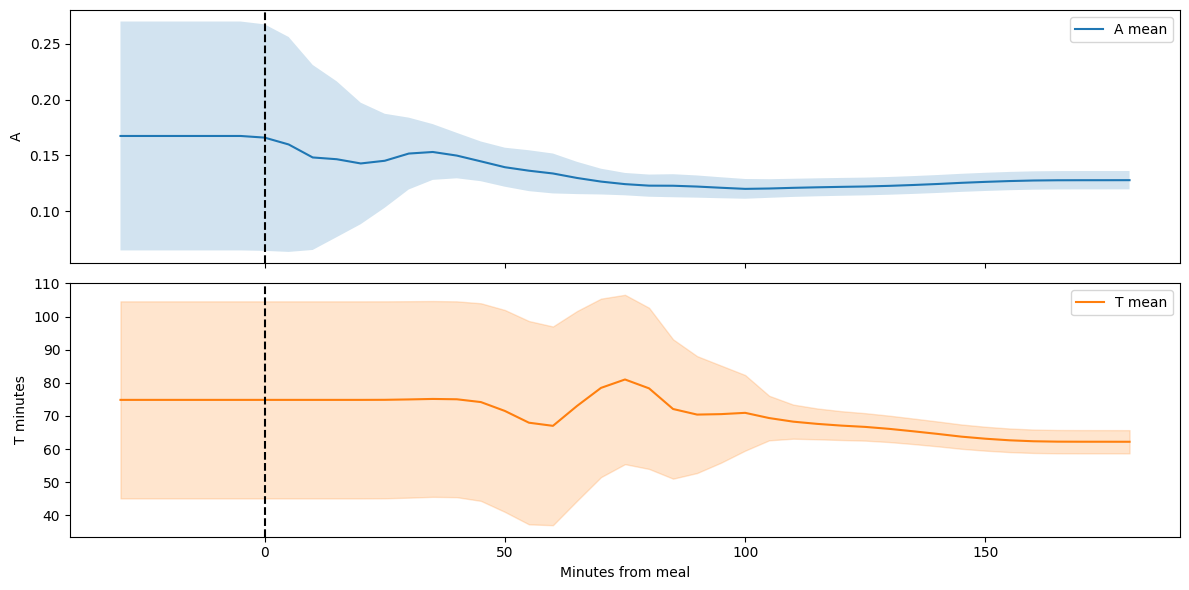

In [9]:
# =========================================================
# ONLINE FORECAST EVOLUTION
# =========================================================

forecast_times = [0, 30, 60, 120]
forecast_indices = [index_nearest(result["time"], t) for t in forecast_times]

fig, ax = plt.subplots(1, 1, figsize=(12, 6))

ax.plot(
    example_sample["time"],
    example_sample["glucose"],
    linewidth=3,
    color="black",
    label="Observed",
)

for idx in forecast_indices:
    pred = posterior_predictive_summary(result, posterior_idx=idx)

    ax.plot(
        result["time"],
        pred["mean"],
        linewidth=2,
        label=f"Forecast at t={result['time'][idx]:.0f}",
    )

    ax.fill_between(
        result["time"],
        pred["low"],
        pred["high"],
        alpha=0.15,
    )

    ax.axvline(result["time"][idx], linestyle="--", alpha=0.35)

ax.axvline(0, color="black", linestyle="--")
ax.axhline(180, color="red", linestyle=":", alpha=0.5)
ax.set_title("Mode 2 online Bayesian meal forecast")
ax.set_xlabel("Minutes from meal")
ax.set_ylabel("Glucose")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ax[0].plot(result["time"], result["A_mean_by_time"], label="A mean")
ax[0].fill_between(
    result["time"],
    result["A_mean_by_time"] - result["A_sd_by_time"],
    result["A_mean_by_time"] + result["A_sd_by_time"],
    alpha=0.2,
)
ax[0].axvline(0, color="black", linestyle="--")
ax[0].set_ylabel("A")
ax[0].legend()

ax[1].plot(result["time"], result["T_mean_by_time"], label="T mean", color="tab:orange")
ax[1].fill_between(
    result["time"],
    result["T_mean_by_time"] - result["T_sd_by_time"],
    result["T_mean_by_time"] + result["T_sd_by_time"],
    alpha=0.2,
    color="tab:orange",
)
ax[1].axvline(0, color="black", linestyle="--")
ax[1].set_ylabel("T minutes")
ax[1].set_xlabel("Minutes from meal")
ax[1].legend()
plt.tight_layout()
plt.show()


In [10]:
# =========================================================
# HELD-OUT EVALUATION
# =========================================================


def evaluate_mode2_heldout(ds, indices, max_meals=50, sigma=12.0):
    rows = []

    for idx in tqdm(indices[:max_meals]):
        sample = sample_from_dataset(ds, idx)
        A_prior, T_prior = predict_meal_prior(sample)
        A_grid = make_log_grid(A_prior, *PARAM_BOUNDS["A"], n=25, factor_low=0.25, factor_high=4.0)
        T_grid = make_linear_grid(T_prior, *PARAM_BOUNDS["T"], n=25, width=80.0)

        result_i = online_meal_posterior(
            sample,
            ACKERMAN_DEFAULT,
            A_grid=A_grid,
            T_grid=T_grid,
            sigma=sigma,
            A_prior=A_prior,
            T_prior=T_prior,
            update_start=0.0,
        )

        time = sample["time"]
        post = time >= 0
        baseline = float(np.median(sample["glucose"][time < 0]))
        obs_metrics = response_metrics(time, sample["glucose"], baseline=baseline)

        pre_idx = index_last_before(time, 0.0)
        pre_pred = posterior_predictive_summary(result_i, posterior_idx=pre_idx)["mean"]
        final_pred = posterior_predictive_summary(result_i, posterior_idx=-1)["mean"]
        pre_metrics = response_metrics(time, pre_pred, baseline=baseline)
        final_metrics = response_metrics(time, final_pred, baseline=baseline)
        final_params = posterior_parameter_summary(result_i, posterior_idx=-1)

        rows.append({
            "idx": idx,
            "person_id": sample["person_id"],
            "meal_id": sample["meal_id"],
            "A_prior": A_prior,
            "T_prior": T_prior,
            **final_params,
            "premeal_forecast_rmse": float(np.sqrt(np.mean((pre_pred[post] - sample["glucose"][post]) ** 2))),
            "final_identified_rmse": float(np.sqrt(np.mean((final_pred[post] - sample["glucose"][post]) ** 2))),
            "premeal_peak_error": pre_metrics["peak"] - obs_metrics["peak"],
            "final_peak_error": final_metrics["peak"] - obs_metrics["peak"],
            "premeal_iAUC_error": pre_metrics["iAUC"] - obs_metrics["iAUC"],
            "final_iAUC_error": final_metrics["iAUC"] - obs_metrics["iAUC"],
        })

    return pd.DataFrame(rows)


MAX_MODE2_HELDOUT_EVAL_MEALS = 50
mode2_eval = evaluate_mode2_heldout(
    mode2_dataset,
    test_idx,
    max_meals=MAX_MODE2_HELDOUT_EVAL_MEALS,
)

mode2_summary = mode2_eval[[
    "premeal_forecast_rmse",
    "final_identified_rmse",
    "premeal_peak_error",
    "final_peak_error",
    "premeal_iAUC_error",
    "final_iAUC_error",
    "A_mean",
    "T_mean",
    "A_sd",
    "T_sd",
]].agg(["count", "mean", "median", "std"])

mode2_summary


100%|██████████| 50/50 [04:26<00:00,  5.32s/it]


,premeal_forecast_rmse,final_identified_rmse,premeal_peak_error,final_peak_error,premeal_iAUC_error,final_iAUC_error,A_mean,T_mean,A_sd,T_sd
count,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,31.576176,12.070679,22.143520,-7.694954,3125.655148,-187.018424,0.100553,86.064037,0.007962,6.191028
median,27.574679,11.260940,18.763626,-5.965423,2934.388125,-121.709726,0.099656,85.878685,0.006282,4.416922
std,13.800534,4.529798,32.984430,8.387084,3191.916537,576.446628,0.045434,31.505388,0.008073,5.402475


In [11]:
# =========================================================
# TOP FINAL POSTERIOR COMBINATIONS FOR THE EXAMPLE
# =========================================================

final_post = result["posterior_history"][-1]
flat = final_post.reshape(-1)
order = np.argsort(flat)[::-1][:12]

rows = []
for flat_idx in order:
    t_idx, a_idx = np.unravel_index(flat_idx, final_post.shape)
    rows.append({
        "A_meal": result["A_grid"][a_idx],
        "T_meal": result["T_grid"][t_idx],
        "posterior_probability": flat[flat_idx],
    })

top_posterior_df = pd.DataFrame(rows)
top_posterior_df


,A_meal,T_meal,posterior_probability
0,0.129564,60.114588,0.257818
1,0.129564,64.051345,0.194863
2,0.119418,64.051345,0.178866
3,0.119418,67.988101,0.080391
4,0.140572,60.114588,0.079240
5,0.140572,56.177832,0.067965
6,0.119418,60.114588,0.037848
7,0.129564,56.177832,0.027703
8,0.110066,67.988101,0.022271
9,0.129564,67.988101,0.011116
